## DAG individual neighbourhoods.csv

### 1. Importamos librerías

In [3]:
import json
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

### 2. Carga de datos

In [4]:
# ── Rutas de los ficheros ──────────────────────────────────────────────────────
PATH_CSV     = "../data/neighbourhoods.csv"
PATH_GEOJSON = "../data/neighbourhoods.geojson"
PATH_LISTINGS = "../data/listings.csv"

# Carga del CSV de barrios
df_neighbourhoods = pd.read_csv(PATH_CSV)
print(f"neighbourhoods.csv: {df_neighbourhoods.shape[0]} filas, {df_neighbourhoods.shape[1]} columnas")
print(df_neighbourhoods)
print()

# Carga del GeoJSON 
gdf = gpd.read_file(PATH_GEOJSON)
print(f"neighbourhoods.geojson: {len(gdf)} features")
print(gdf[["neighbourhood", "neighbourhood_group", "geometry"]].head(12))
print()

# Carga de listings (para cruzar barrios) 
df_listings = pd.read_csv(PATH_LISTINGS, usecols=["id", "neighbourhood"])
print(f"listings.csv: {df_listings.shape[0]} filas")
print(df_listings["neighbourhood"].value_counts())
print()

neighbourhoods.csv: 11 filas, 2 columnas
    neighbourhood_group         neighbourhood
0                   NaN     Bailen-Miraflores
1                   NaN           Campanillas
2                   NaN    Carretera de Cadiz
3                   NaN                Centro
4                   NaN             Churriana
5                   NaN         Ciudad Jardin
6                   NaN   Cruz De Humilladero
7                   NaN                  Este
8                   NaN        Palma-Palmilla
9                   NaN    Puerto de la Torre
10                  NaN  Teatinos-Universidad

neighbourhoods.geojson: 11 features
           neighbourhood neighbourhood_group  \
0              Churriana                None   
1     Carretera de Cadiz                None   
2   Teatinos-Universidad                None   
3         Palma-Palmilla                None   
4          Ciudad Jardin                None   
5                   Este                None   
6                 Centro          

### 2. Exploración inicial

In [5]:
# Tipos de datos y nulos en neighbourhoods.csv 
print("- Tipos de datos")
print(df_neighbourhoods.dtypes)
print()
print("- Valores nulos por columna")
print(df_neighbourhoods.isnull().sum())
print()
print("- Valores únicos por columna")
for col in df_neighbourhoods.columns:
    print(f"  {col}: {df_neighbourhoods[col].nunique()} únicos → {df_neighbourhoods[col].unique()}")

- Tipos de datos
neighbourhood_group    float64
neighbourhood              str
dtype: object

- Valores nulos por columna
neighbourhood_group    11
neighbourhood           0
dtype: int64

- Valores únicos por columna
  neighbourhood_group: 0 únicos → [nan]
  neighbourhood: 11 únicos → <StringArray>
[   'Bailen-Miraflores',          'Campanillas',   'Carretera de Cadiz',
               'Centro',            'Churriana',        'Ciudad Jardin',
  'Cruz De Humilladero',                 'Este',       'Palma-Palmilla',
   'Puerto de la Torre', 'Teatinos-Universidad']
Length: 11, dtype: str


In [6]:
# Exploración del GeoJSON 
print("- Nulos en GeoJSON")
print(gdf[["neighbourhood", "neighbourhood_group"]].isnull().sum())

- Nulos en GeoJSON
neighbourhood           0
neighbourhood_group    11
dtype: int64


### 3- Limpieza y validación

In [7]:
# 3.1 Eliminar columna neighbourhood_group (vacía al 100%) 
print("Antes:", df_neighbourhoods.columns.tolist())
df_neighbourhoods = df_neighbourhoods.drop(columns=["neighbourhood_group"])
gdf = gdf.drop(columns=["neighbourhood_group"])
print("Después:", df_neighbourhoods.columns.tolist())

Antes: ['neighbourhood_group', 'neighbourhood']
Después: ['neighbourhood']


In [8]:
# 3.2 Verificar que los barrios del CSV y el GeoJSON coinciden 
barrios_csv = set(df_neighbourhoods["neighbourhood"])
barrios_geo = set(gdf["neighbourhood"])

solo_en_csv = barrios_csv - barrios_geo
solo_en_geo = barrios_geo - barrios_csv

if not solo_en_csv and not solo_en_geo:
    print("[CORRECTO] CSV y GeoJSON tienen exactamente los mismos 11 barrios.")
else:
    print(f"[AVISO] Solo en CSV: {solo_en_csv}")
    print(f"[AVISO] Solo en GeoJSON: {solo_en_geo}")

[CORRECTO] CSV y GeoJSON tienen exactamente los mismos 11 barrios.


In [9]:
# 3.3 Verificar que los barrios de listings coinciden con los conocidos 
barrios_listings = set(df_listings["neighbourhood"].dropna().unique())
barrios_conocidos = barrios_csv

desconocidos = barrios_listings - barrios_conocidos
print(f"Barrios en listings no presentes en neighbourhoods.csv: {desconocidos}")

# Listings sin barrio asignado (NaN)
nulos_barrio = df_listings["neighbourhood"].isnull().sum()
print(f"Listings sin barrio (NaN): {nulos_barrio}")

Barrios en listings no presentes en neighbourhoods.csv: set()
Listings sin barrio (NaN): 0


### 4. Transformación de Datos

In [10]:
# 4.1 Definir agrupación geográfica de barrios 
# Basada en proximidad geográfica dentro de Málaga
GRUPOS_BARRIOS = {
    "Centro"   : ["Centro"],
    "Este"     : ["Este"],
    "Oeste"    : ["Carretera de Cadiz", "Cruz De Humilladero", "Teatinos-Universidad"],
    "Norte"    : ["Bailen-Miraflores", "Palma-Palmilla", "Ciudad Jardin"],
    "Periferia": ["Churriana", "Campanillas", "Puerto de la Torre"],
}

# Construir mapa inverso: {barrio: grupo}
mapa_barrio_grupo = {
    barrio: grupo
    for grupo, barrios in GRUPOS_BARRIOS.items()
    for barrio in barrios
}

print("Mapa barrio -> grupo:")
for k, v in mapa_barrio_grupo.items():
    print(f"  {k:30s} -> {v}")

Mapa barrio -> grupo:
  Centro                         -> Centro
  Este                           -> Este
  Carretera de Cadiz             -> Oeste
  Cruz De Humilladero            -> Oeste
  Teatinos-Universidad           -> Oeste
  Bailen-Miraflores              -> Norte
  Palma-Palmilla                 -> Norte
  Ciudad Jardin                  -> Norte
  Churriana                      -> Periferia
  Campanillas                    -> Periferia
  Puerto de la Torre             -> Periferia


In [11]:
# 4.2 Asignar neighbourhood_group al CSV y al GeoJSON 
df_neighbourhoods["neighbourhood_group"] = (
    df_neighbourhoods["neighbourhood"].map(mapa_barrio_grupo)
)

gdf["neighbourhood_group"] = (
    gdf["neighbourhood"].map(mapa_barrio_grupo)
)

print(df_neighbourhoods)

           neighbourhood neighbourhood_group
0      Bailen-Miraflores               Norte
1            Campanillas           Periferia
2     Carretera de Cadiz               Oeste
3                 Centro              Centro
4              Churriana           Periferia
5          Ciudad Jardin               Norte
6    Cruz De Humilladero               Oeste
7                   Este                Este
8         Palma-Palmilla               Norte
9     Puerto de la Torre           Periferia
10  Teatinos-Universidad               Oeste


### 5. Enriquecimiento de Datos 

In [ ]:
# Agregamos los datos de listings por barrio
stats_barrios = df_listings.groupby('neighbourhood').agg(
    num_anuncios=('id', 'count')
).reset_index()

# Calculamos el % de representatividad sobre el total de Málaga
total_anuncios = stats_barrios['num_anuncios'].sum()
stats_barrios['pct_total'] = (stats_barrios['num_anuncios'] / total_anuncios) * 100

print("Estadísticas calculadas por barrio:")
print(stats_barrios.sort_values(by='num_anuncios', ascending=False))

Estadísticas calculadas por barrio:
           neighbourhood  num_anuncios  pct_total
3                 Centro          6389  65.771052
7                   Este           989  10.181182
2     Carretera de Cadiz           935   9.625283
6    Cruz De Humilladero           460   4.735433
0      Bailen-Miraflores           312   3.211859
8         Palma-Palmilla           217   2.233889
4              Churriana           150   1.544163
10  Teatinos-Universidad           100   1.029442
5          Ciudad Jardin            88   0.905909
9     Puerto de la Torre            41   0.422071
1            Campanillas            33   0.339716


In [14]:
# Unimos al DataFrame de barrios
df_neighbourhoods = df_neighbourhoods.merge(stats_barrios, on='neighbourhood', how='left')

# Unimos al GeoDataFrame para las visualizaciones
gdf = gdf.merge(stats_barrios, on='neighbourhood', how='left')

# Rellenamos con 0 si algún barrio no tuviera anuncios (integridad)
df_neighbourhoods['num_anuncios'] = df_neighbourhoods['num_anuncios'].fillna(0)

### 6. Visualización de Datos

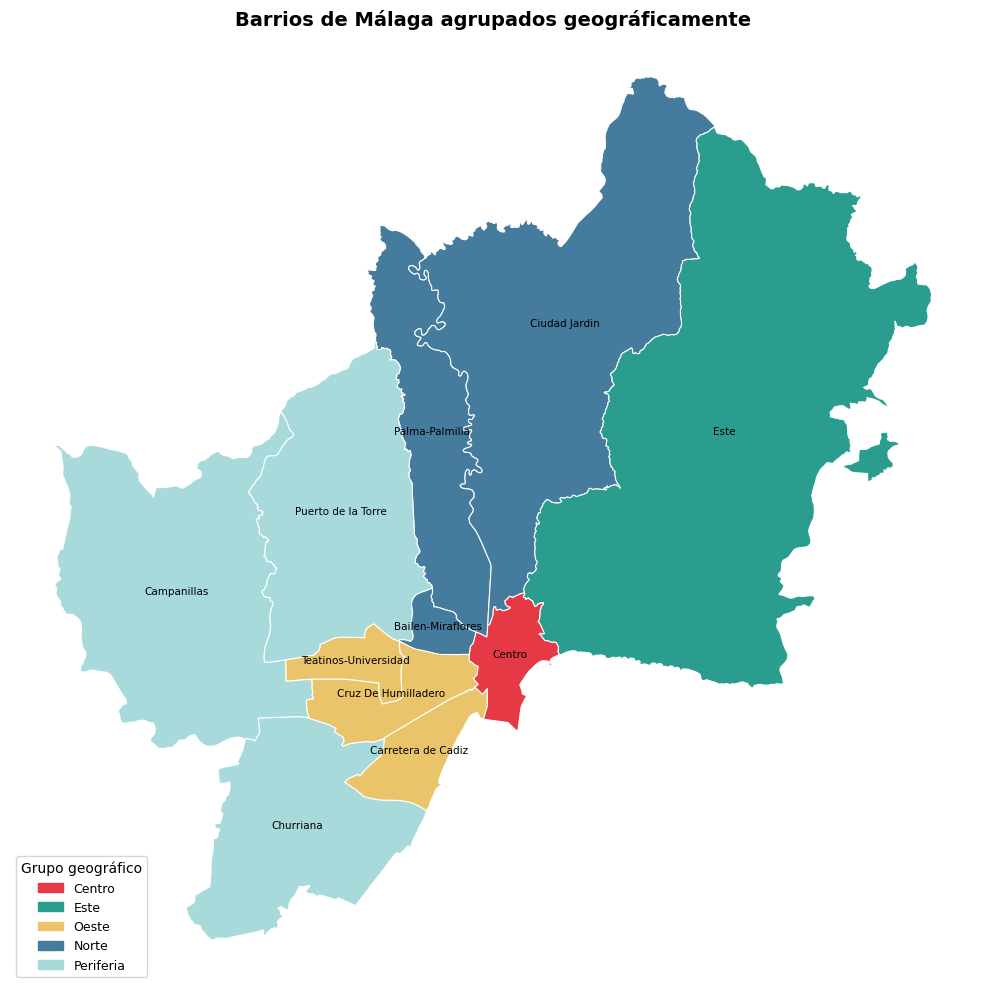

In [13]:
# ── 5.1 Mapa de barrios coloreado por grupo geográfico ────────────────────────
COLORES_GRUPOS = {
    "Centro"   : "#e63946",
    "Este"     : "#2a9d8f",
    "Oeste"    : "#e9c46a",
    "Norte"    : "#457b9d",
    "Periferia": "#a8dadc",
}

gdf["color"] = gdf["neighbourhood_group"].map(COLORES_GRUPOS)

fig, ax = plt.subplots(figsize=(10, 10))
gdf.plot(ax=ax, color=gdf["color"], edgecolor="white", linewidth=0.8)

# Etiquetas con el nombre de cada barrio
for _, row in gdf.iterrows():
    centroid = row.geometry.centroid
    ax.annotate(
        text=row["neighbourhood"],
        xy=(centroid.x, centroid.y),
        fontsize=7.5,
        ha="center",
        color="black"
    )

# Leyenda por grupo
leyenda = [
    mpatches.Patch(color=color, label=grupo)
    for grupo, color in COLORES_GRUPOS.items()
]
ax.legend(handles=leyenda, title="Grupo geográfico", loc="lower left", fontsize=9)

ax.set_title("Barrios de Málaga agrupados geográficamente", fontsize=14, fontweight="bold")
ax.set_axis_off()
plt.tight_layout()
plt.show()

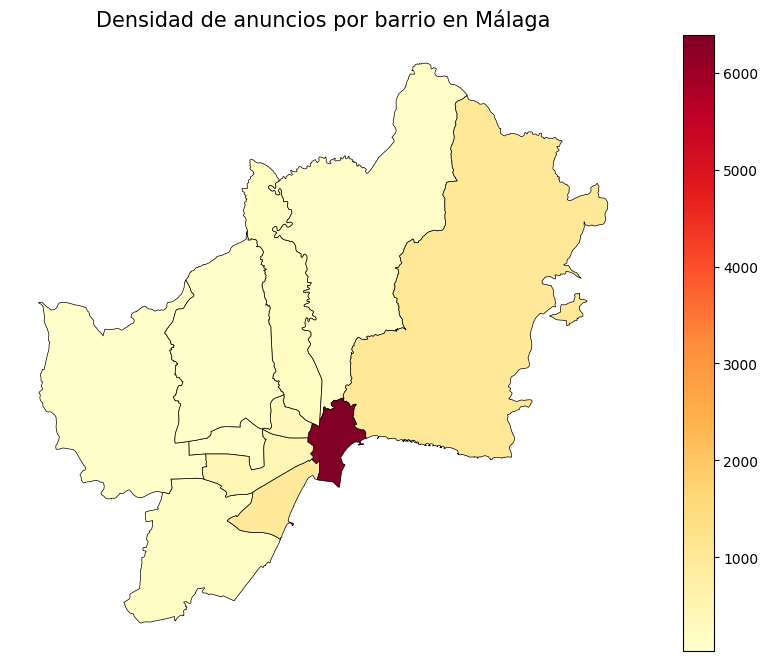

In [17]:
fig, ax = plt.subplots(figsize=(12, 8))

# Dibujamos el mapa usando la columna 'num_anuncios' para el color
gdf.plot(column='num_anuncios', 
         cmap='YlOrRd', 
         legend=True, 
         edgecolor='black', 
         linewidth=0.5, 
         ax=ax)

ax.set_title('Densidad de anuncios por barrio en Málaga', fontsize=15)
ax.set_axis_off()
plt.show()

,neighbourhood,neighbourhood_group,num_anuncios,pct_total
0,Bailen-Miraflores,Norte,312,3.211859
1,Campanillas,Periferia,33,0.339716
2,Carretera de Cadiz,Oeste,935,9.625283
3,Centro,Centro,6389,65.771052
4,Churriana,Periferia,150,1.544163
